In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600.csv.csv")
print(df.head)


<bound method NDFrame.head of       customer_id   age  gender   region employment_type  annual_income_inr  \
0          500001  43.0  Female      NaN        Salaried            82242.0   
1          500002  29.0  Female  Central        Salaried            32769.0   
2          500003  36.0    Male     East        Salaried            39731.0   
3          500004  28.0    Male    North      Unemployed            38990.0   
4          500005  36.0  Female     East   Self-Employed            41043.0   
...           ...   ...     ...      ...             ...                ...   
4595       504596  40.0    Male    North             NaN            39337.0   
4596       504597  35.0  Female  Central      Unemployed            34465.0   
4597       504598  31.0  Female     East   Self-Employed                NaN   
4598       504599  43.0    Male     East        Salaried            15000.0   
4599       504600  43.0  Female    South        Salaried            25325.0   

      credit_score  c

In [5]:
# PART B #
# 1 #

# Target Variable
y = df["risk_status"]

# Input Features
X = df.drop("risk_status", axis=1)

print("Input Features:")
print(X.columns)

print("\nTarget Variable:")
print(y.name)


X = pd.get_dummies(X, drop_first=True)


# 2 #

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTrain Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Class Distribution:")
print(y_test.value_counts(normalize=True))

# 3 #

print("\nMissing Values:")
print(X_train.isnull().sum())

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)



Input Features:
Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr'],
      dtype='object')

Target Variable:
risk_status

Training Data Shape: (3680, 113)
Testing Data Shape: (920, 113)

Train Class Distribution:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Test Class Distribution:
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64

Missing Values:
customer_id                           0
age                                 116
annual_income_inr                   132
credit_score                        181
credit_utilization_ratio            118
                                

In [6]:
# PART C #

# 1 #

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(y_pred)

# 2 #

# CONFUSION MATRIX #

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ACCURACY SCORE

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# PRECISION, RECALL AND F1-SCORE

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3 #

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

print("\nType I Error (False Positive):", FP)
print("Type II Error (False Negative):", FN)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 0
 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 1 0 0 0 0 

In [7]:
# PART D #

methods = {
    "Under": RandomUnderSampler(random_state=42),
    "Over": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

results = []

# Baseline
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
prob = model.predict_proba(X_test_scaled)[:, 1]

results.append(["Baseline", recall_score(y_test, pred),
                f1_score(y_test, pred), roc_auc_score(y_test, prob)])

# Sampling methods
for name, sampler in methods.items():
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_res, y_res)

    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append([name, recall_score(y_test, pred),
                    f1_score(y_test, pred),
                    roc_auc_score(y_test, prob)])

print(pd.DataFrame(results, columns=["Method", "Recall", "F1", "AUC-ROC"]))


     Method  Recall        F1   AUC-ROC
0  Baseline     1.0  1.000000  1.000000
1     Under     1.0  0.973684  0.999855
2      Over     1.0  0.991071  1.000000
3     SMOTE     1.0  0.995516  1.000000
4    ADASYN     1.0  1.000000  1.000000


In [8]:
# PART E #

from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(
        y_train,
        model.predict(X_train_scaled)
    )

    test_acc = accuracy_score(
        y_test,
        model.predict(X_test_scaled)
    )

    results.append([name, train_acc, test_acc])

print(pd.DataFrame(
    results,
    columns=["Model", "Train Accuracy", "Test Accuracy"]
))

           Model  Train Accuracy  Test Accuracy
0  Decision Tree             1.0       0.968478
1  Random Forest             1.0       0.996739


In [9]:
# PART F #

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Randomized Search
params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    n_iter=5,
    cv=5,
    scoring="f1",
    random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Random Best:", random_search.best_params_)


# Grid Search
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train_scaled, y_train)

print("Grid Best:", grid_search.best_params_)


# Tuned vs Untuned
untuned = RandomForestClassifier(
    random_state=42
).fit(X_train_scaled, y_train)

print("\nUntuned Accuracy:",
      accuracy_score(y_test, untuned.predict(X_test_scaled)))

print("Tuned Accuracy:",
      accuracy_score(
          y_test,
          grid_search.best_estimator_.predict(X_test_scaled)
      ))

Random Best: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
Grid Best: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Untuned Accuracy: 0.9967391304347826
Tuned Accuracy: 0.9978260869565218


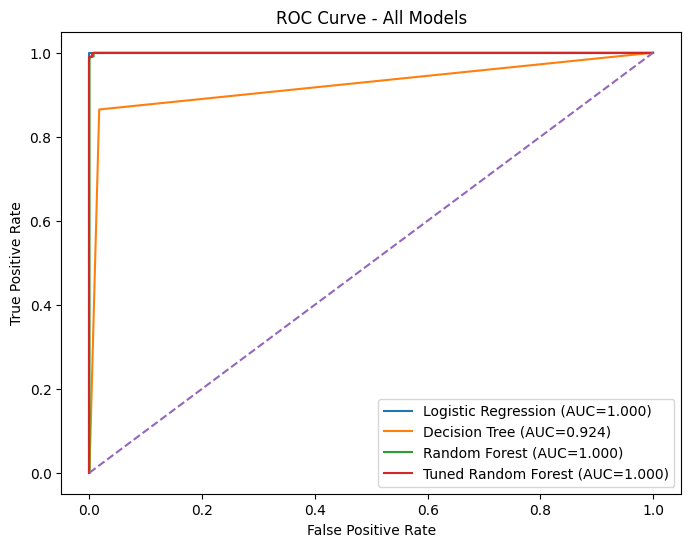

Logistic Regression AUC-ROC: 1.0
Decision Tree AUC-ROC: 0.924
Random Forest AUC-ROC: 1.0
Tuned Random Forest AUC-ROC: 1.0
                 Model  False Negatives    Recall
0  Logistic Regression                0  1.000000
1        Decision Tree               15  0.864865
2        Random Forest                3  0.972973
3  Tuned Random Forest                2  0.981982

Best Final Model: Logistic Regression


In [13]:
# PART G #
# 1 #
import matplotlib.pylab as plt
from sklearn.metrics import (roc_curve)


baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_scaled, y_train)


dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

models = {
    "Logistic Regression": baseline_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": grid_search.best_estimator_
}

# ROC Plot
plt.figure(figsize=(8, 6))

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)

    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()

# 2 #

for name, model in models.items():

    prob = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, prob)

    print(name, "AUC-ROC:", round(auc, 3))

# 3 #

from sklearn.metrics import confusion_matrix, recall_score

results = []

for name, model in models.items():

    pred = model.predict(X_test_scaled)

    tn, fp, fn, tp = confusion_matrix(
        y_test, pred
    ).ravel()

    recall = recall_score(y_test, pred)

    results.append([
        name,
        fn,
        recall
    ])

result_df = pd.DataFrame(
    results,
    columns=["Model", "False Negatives", "Recall"]
)

print(result_df)

# Best model = minimum False Negatives
best_model_name = result_df.loc[
    result_df["False Negatives"].idxmin(),
    "Model"
]

print("\nBest Final Model:", best_model_name)

In [16]:
# PART H #

# 1 #
final_results = []

for name, model in models.items():

    pred = model.predict(X_test_scaled)
    prob = model.predict_proba(X_test_scaled)[:, 1]

    tn, fp, fn, tp = confusion_matrix(
        y_test, pred
    ).ravel()

    final_results.append([
        name,
        accuracy_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob),
        fp,
        fn
    ])

final_df = pd.DataFrame(
    final_results,
    columns=[
        "Model",
        "Accuracy",
        "Recall",
        "F1 Score",
        "AUC-ROC",
        "False Positive",
        "False Negative"
    ]
)
print(final_df.round(3))

best_row = final_df.loc[
    final_df["False Negative"].idxmin()
]

print("\n========== FINAL CONCLUSION ==========")

print("Best Model:", best_row["Model"])
print("Accuracy:", round(best_row["Accuracy"], 3))
print("Recall:", round(best_row["Recall"], 3))
print("F1 Score:", round(best_row["F1 Score"], 3))
print("AUC-ROC:", round(best_row["AUC-ROC"], 3))
print("False Negatives:", best_row["False Negative"])

print("""
Business Recommendation:
The selected model is preferred because the business
requirement is to minimize False Negatives.

In credit risk prediction, a False Negative means that
a High-Risk customer is incorrectly classified as Low Risk.
This can lead to financial loss and increased credit risk.
""")

# 2 #

print(final_df.round(3))

                 Model  Accuracy  Recall  F1 Score  AUC-ROC  False Positive  \
0  Logistic Regression     1.000   1.000     1.000    1.000               0   
1        Decision Tree     0.968   0.865     0.869    0.924              14   
2        Random Forest     0.997   0.973     0.986    1.000               0   
3  Tuned Random Forest     0.998   0.982     0.991    1.000               0   

   False Negative  
0               0  
1              15  
2               3  
3               2  

========== FINAL CONCLUSION ==========
Best Model: Logistic Regression
Accuracy: 1.0
Recall: 1.0
F1 Score: 1.0
AUC-ROC: 1.0
False Negatives: 0

Business Recommendation:
The selected model is preferred because the business
requirement is to minimize False Negatives.

In credit risk prediction, a False Negative means that
a High-Risk customer is incorrectly classified as Low Risk.
This can lead to financial loss and increased credit risk.

                 Model  Accuracy  Recall  F1 Score  AUC-ROC  